In [1]:
!pip install openpyxl
!pip install siuba
!pip install matplotlib
!pip install seaborn

import pandas as pd
import json
from siuba import _, filter, arrange, select, mutate, group_by, summarize, count
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
vuelos = pd.read_csv("flight_data_2024.csv")
vuelos

/var/folders/cn/vnbd0r_j07x20nbs2_dk9dxm0000gn/T/ipykernel_34078/1589301917.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  vuelos = pd.read_csv("flight_data_2024.csv")


In [ ]:
with open('Airports.json', 'r', encoding='utf-8') as file:
    json1 = json.load(file)
print(json.dumps(json1, indent=1, ensure_ascii =False)) 

[
 {
  "Rank": 1,
  "Airport": "United States Hartsfield–Jackson Atlanta International Airport",
  "Location": "Atlanta, Georgia",
  "Country": "United States",
  "Code": "ATL/KATL",
  "Passengers": 104171935,
  "Year": 2016
 },
 {
  "Rank": 2,
  "Airport": "China Beijing Capital International Airport",
  "Location": "Chaoyang-Shunyi, Beijing",
  "Country": "China",
  "Code": "PEK/ZBAA",
  "Passengers": 94393454,
  "Year": 2016
 },
 {
  "Rank": 3,
  "Airport": "United Arab Emirates Dubai International Airport",
  "Location": "Garhoud, Dubai",
  "Country": "United Arab Emirates",
  "Code": "DXB/OMDB",
  "Passengers": 83654250,
  "Year": 2016
 },
 {
  "Rank": 4,
  "Airport": "United States Los Angeles International Airport",
  "Location": "Los Angeles, California",
  "Country": "United States",
  "Code": "LAX/KLAX",
  "Passengers": 80921527,
  "Year": 2016
 },
 {
  "Rank": 5,
  "Airport": "Japan Tokyo Haneda Airport",
  "Location": "Ōta, Tokyo",
  "Country": "Japan",
  "Code": "HND/RJTT"

In [ ]:
type(json1)
json1df = pd.json_normalize(json1)
json1df.head()

,Rank,Airport,Location,Country,Code,Passengers,Year
0,1,United States Hartsfield–Jackson Atlanta Inter...,"Atlanta, Georgia",United States,ATL/KATL,104171935,2016
1,2,China Beijing Capital International Airport,"Chaoyang-Shunyi, Beijing",China,PEK/ZBAA,94393454,2016
2,3,United Arab Emirates Dubai International Airport,"Garhoud, Dubai",United Arab Emirates,DXB/OMDB,83654250,2016
3,4,United States Los Angeles International Airport,"Los Angeles, California",United States,LAX/KLAX,80921527,2016
4,5,Japan Tokyo Haneda Airport,"Ōta, Tokyo",Japan,HND/RJTT,79699762,2016


In [ ]:
json1df[['Code', 'code_icao']] = json1df['Code'].str.split('/', expand=True)
json1df[['Code', 'code_icao']].head()

,Code,code_icao
0,ATL,KATL
1,PEK,ZBAA
2,DXB,OMDB
3,LAX,KLAX
4,HND,RJTT


In [ ]:
data = pd.ExcelFile('us-airports.xlsx')
data

In [ ]:
df_airports = data.parse(0) 
df_airports.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,country_name,iso_country,...,scheduled_service,gps_code,icao_code,iata_code,local_code,home_link,wikipedia_link,keywords,score,last_updated
0,3632,KLAX,large_airport,Los Angeles International Airport,33.942501,-118.407997,125.0,NaN,United States,US,...,1,KLAX,KLAX,LAX,LAX,https://www.flylax.com/,https://en.wikipedia.org/wiki/Los_Angeles_Inte...,Tom Bradley,1335475.0,2024-04-02T16:36:13+00:00
1,3754,KORD,large_airport,Chicago O'Hare International Airport,41.978600,-87.904800,680.0,NaN,United States,US,...,1,KORD,KORD,ORD,ORD,https://www.flychicago.com/ohare/home/pages/de...,https://en.wikipedia.org/wiki/O'Hare_Internati...,"CHI, Orchard Place",1503175.0,2024-03-09T23:28:49+00:00
2,3622,KJFK,large_airport,John F. Kennedy International Airport,40.639447,-73.779317,13.0,NaN,United States,US,...,1,KJFK,KJFK,JFK,JFK,https://www.jfkairport.com/,https://en.wikipedia.org/wiki/John_F._Kennedy_...,"Manhattan, New York City, NYC, Idlewild, IDL, ...",1052075.0,2026-01-12T15:26:18+00:00
3,3384,KATL,large_airport,Hartsfield Jackson Atlanta International Airport,33.636700,-84.428101,1026.0,NaN,United States,US,...,1,KATL,KATL,ATL,ATL,https://www.atl.com,https://en.wikipedia.org/wiki/Hartsfield–Jacks...,NaN,2002475.0,2025-09-12T16:52:18+00:00
4,3878,KSFO,large_airport,San Francisco International Airport,37.619806,-122.374821,13.0,NaN,United States,US,...,1,KSFO,KSFO,SFO,SFO,http://www.flysfo.com/,https://en.wikipedia.org/wiki/San_Francisco_In...,"QSF, QBA",1112475.0,2024-04-02T16:43:50+00:00


In [ ]:
df_airports['score'] = df_airports['score'].fillna(method='ffill')
print(df_airports['score'].isna().sum())

0


In [ ]:
df_airports['scheduled_service'] = df_airports['scheduled_service'].replace({
    1: 'Servicio programado',
    0: 'Sin servicio programado'
})

In [ ]:
vuelos_final = vuelos.merge(json1df, left_on='origin', right_on='Code', how='left') \
                    .merge(df_airports, left_on='origin', right_on='local_code', how='left')

In [ ]:
columnas_a_eliminar = [
    'Location', 'Country', 'Code', 'id', 'ident', 
    'continent', 'iso_country', 'iso_region', 'local_region', 
    'municipality', 'scheduled_service', 'gps_code', 'icao_code', 
    'iata_code', 'local_code', 'keywords', 'last_updated', 'country_name', 'Year'
    , 'name', 'elevation_ft', 'home_link', 'wikipedia_link', 'region_name', 'cancellation_code']

vuelos = vuelos_final.drop(columns=columnas_a_eliminar)
vuelos.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,security_delay,late_aircraft_delay,Rank,Airport,Passengers,code_icao,type,latitude_deg,longitude_deg,score
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,0,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,0,49.0,United States Minneapolis/St Paul Internationa...,37413728.0,KMSP,large_airport,44.880081,-93.221741,1085275.0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,0,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,0,NaN,NaN,NaN,NaN,large_airport,37.505199,-77.319702,1475.0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,0,NaN,NaN,NaN,NaN,large_airport,42.213770,-83.353786,1079375.0


In [ ]:
vuelos = vuelos.rename(columns={
    'op_unique_carrier': 'aerolinea',
})

vuelos['aerolinea'] = vuelos['aerolinea'].astype('category')
vuelos['origin'] = vuelos['origin'].astype('category')
vuelos['dest'] = vuelos['dest'].astype('category')
vuelos['origin_state_nm'] = vuelos['origin_state_nm'].astype('category')
vuelos['dest_state_nm'] = vuelos['dest_state_nm'].astype('category')

vuelos['cancelled'] = vuelos['cancelled'].astype(bool)
vuelos['diverted'] = vuelos['diverted'].astype(bool)

vuelos['is_delayed'] = (vuelos['arr_delay'] > 15).astype(int)
vuelos['fl_date'] = pd.to_datetime(vuelos['fl_date'])

In [ ]:
def clasificar_retraso(minutos):
    if minutos < -7:
        return 'Adelantado'
    elif -7 <= minutos <= 7:
        return 'Sin retraso o casi sin retraso'
    else:
        return 'Retrasado'

vuelos['tipo_retraso'] = vuelos['arr_delay'].apply(clasificar_retraso)

print(vuelos['tipo_retraso'].value_counts())
print("\nPorcentajes:")
print(vuelos['tipo_retraso'].value_counts(normalize=True).round(3) * 100)

tipo_retraso
Adelantado                        3231605
Retrasado                         1980415
Sin retraso o casi sin retraso    1867061
Name: count, dtype: int64

Porcentajes:
tipo_retraso
Adelantado                        45.7
Retrasado                         28.0
Sin retraso o casi sin retraso    26.4
Name: proportion, dtype: float64


In [ ]:
vuelos.to_feather('vuelos_2024_limpio.feather')

In [ ]:
vuelos = pd.read_feather('vuelos_2024_limpio.feather')
vuelos

,year,month,day_of_month,day_of_week,fl_date,aerolinea,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,Rank,Airport,Passengers,code_icao,type,latitude_deg,longitude_deg,score,is_delayed,tipo_retraso
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Adelantado
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,49.0,United States Minneapolis/St Paul Internationa...,37413728.0,KMSP,large_airport,44.880081,-93.221741,1085275.0,0,Adelantado
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Adelantado
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,NaN,None,NaN,None,large_airport,37.505199,-77.319702,1475.0,0,Adelantado
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,NaN,None,NaN,None,large_airport,42.213770,-83.353786,1079375.0,0,Adelantado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7079076,2024,12,31,2,2024-12-31,YX,5857.0,MYR,"Myrtle Beach, SC",South Carolina,...,NaN,None,NaN,None,large_airport,33.679699,-78.928299,1000.0,0,Adelantado
7079077,2024,12,31,2,2024-12-31,YX,5859.0,JFK,"New York, NY",New York,...,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Adelantado
7079078,2024,12,31,2,2024-12-31,YX,5859.0,PWM,"Portland, ME",Maine,...,NaN,None,NaN,None,large_airport,43.646198,-70.309303,1275.0,0,Adelantado
7079079,2024,12,31,2,2024-12-31,YX,5862.0,JFK,"New York, NY",New York,...,16.0,United States John F. Kennedy International Ai...,58813103.0,KJFK,large_airport,40.639447,-73.779317,1052075.0,0,Adelantado


**MODELIZACIÓN**

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [18]:
numericas   = ['crs_dep_time', 'crs_arr_time', 
               'crs_elapsed_time', 'distance']
categoricas = ['aerolinea', 'origin', 'dest','month', 'day_of_month', 'day_of_week']

In [19]:
X = vuelos[numericas + categoricas].copy()

In [20]:
y=vuelos['tipo_retraso']

In [21]:
X.isna().sum()

crs_dep_time        0
crs_arr_time        0
crs_elapsed_time    1
distance            0
aerolinea           0
origin              0
dest                0
month               0
day_of_month        0
day_of_week         0
dtype: int64

In [22]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer

In [23]:
X_sample = X.sample(n=100000, random_state=42)
y_sample = y[X_sample.index]

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.1, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 90000 | Test: 10000


In [24]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ct = make_column_transformer(
    (ohe, categoricas),
    remainder='passthrough'
)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [25]:
y_sample.value_counts()

tipo_retraso
Adelantado                        45932
Retrasado                         27861
Sin retraso o casi sin retraso    26207
Name: count, dtype: int64

**GRIDSEARCHCSV (knn)** 

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 7, 15, 21], 
    'weights': ['uniform', 'distance'],  
    'metric': ['euclidean'] 
}

In [27]:
grid_knn = GridSearchCV(
    knn, 
    param_grid_knn, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_knn.fit(X_train[:10000], y_train[:10000])

print(f"Mejor K encontrado: {grid_knn.best_params_}")

Mejor K encontrado: {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'uniform'}


**Vecinos mas cercanos**

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [29]:
knn = KNeighborsClassifier(
    n_neighbors=21, 
    metric='euclidean', 
    weights='uniform'
)

In [30]:
knn = KNeighborsClassifier(n_neighbors=21, metric='euclidean', weights='uniform')
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",21
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [31]:
y_pred= knn.predict(X_test)

In [32]:
knn.score(X_test,y_test)

0.4496

In [33]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[3539,  732,  353],
       [1882,  683,  244],
       [1824,  469,  274]])

In [34]:
cr=classification_report(y_test,y_pred)
print(cr)

                                precision    recall  f1-score   support

                    Adelantado       0.49      0.77      0.60      4624
                     Retrasado       0.36      0.24      0.29      2809
Sin retraso o casi sin retraso       0.31      0.11      0.16      2567

                      accuracy                           0.45     10000
                     macro avg       0.39      0.37      0.35     10000
                  weighted avg       0.41      0.45      0.40     10000



**Árboles de decisión**

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

dtc_base = DecisionTreeClassifier()

param_dist_dtc = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],     
    'min_samples_split': [2, 5, 10],     
    'min_samples_leaf': [1, 2, 4]         
}

random_dtc = RandomizedSearchCV(
    dtc_base, 
    param_distributions=param_dist_dtc, 
    n_iter=10, 
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

random_dtc.fit(X_train[:10000], y_train[:10000])

print(f"Mejores parámetros para Árbol: {random_dtc.best_params_}")

Mejores parámetros para Árbol: {'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'criterion': 'entropy'}


In [36]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=10,
)

In [37]:
dtc.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

In [38]:
y_pred=dtc.predict(X_test)

In [39]:
confusion_matrix(y_test,y_pred)

array([[4130,  424,   70],
       [2087,  660,   62],
       [2101,  386,   80]])

In [40]:
print(classification_report(y_test,y_pred))

                                precision    recall  f1-score   support

                    Adelantado       0.50      0.89      0.64      4624
                     Retrasado       0.45      0.23      0.31      2809
Sin retraso o casi sin retraso       0.38      0.03      0.06      2567

                      accuracy                           0.49     10000
                     macro avg       0.44      0.39      0.33     10000
                  weighted avg       0.45      0.49      0.40     10000



**Random forest**

MUY CURIOSO PORQUE SE VUELVE "VAGO"

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

param_grid_rf = {
    'n_estimators': [50, 100],      
    'max_depth': [10, 20, None],   
    'min_samples_split': [2, 5]    
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,                          
    scoring='accuracy',
    n_jobs=-1                       
)

grid_rf.fit(X_train[:10000], y_train[:10000])

print(f"Mejores parámetros RF: {grid_rf.best_params_}")

Mejores parámetros RF: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


In [42]:
rf = RandomForestClassifier(
    max_depth=20, 
    min_samples_split=5, 
    n_estimators=100, 
)

In [43]:
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [44]:
y_pred =rf.predict(X_test)

In [45]:
rf.score(X_test,y_test)

0.4962

In [46]:
print(classification_report(y_test,y_pred))

                                precision    recall  f1-score   support

                    Adelantado       0.49      0.95      0.65      4624
                     Retrasado       0.54      0.19      0.28      2809
Sin retraso o casi sin retraso       0.66      0.02      0.04      2567

                      accuracy                           0.50     10000
                     macro avg       0.56      0.39      0.32     10000
                  weighted avg       0.55      0.50      0.39     10000



"Tras comparar los tres modelos, se selecciona el Árbol de Decisión como el modelo definitivo. A pesar de que el Random Forest tiene un accuracy ligeramente superior (0.63 vs 0.62), el Árbol de Decisión demuestra una mayor capacidad para identificar las clases minoritarias de retraso, obteniendo el mejor Macro F1-Score (0.18). Los otros modelos tienden a ignorar los retrasos por completo para maximizar el acierto en los vuelos puntuales."

In [47]:
from sklearn.model_selection import cross_val_score
import numpy as np

cvscore_dtc = cross_val_score(dtc, X_train[:10000], y_train[:10000], cv=10, scoring='f1_macro')

print("Resultados por pliegue (F1-Macro):", cvscore_dtc)
print("Media F1-Macro:", np.mean(cvscore_dtc))
print("Desviación Estándar:", np.std(cvscore_dtc))

Resultados por pliegue (F1-Macro): [0.32505227 0.34119896 0.35732032 0.32874689 0.33006261 0.36086841
 0.35802968 0.35703683 0.36043509 0.31745872]
Media F1-Macro: 0.3436209753680949
Desviación Estándar: 0.016111023564022137


**NUEVO TIPO DE PREDICCIÓN -> RETRASADO O NO**

In [48]:
X2 = X.copy()
X2

,crs_dep_time,crs_arr_time,crs_elapsed_time,distance,aerolinea,origin,dest,month,day_of_month,day_of_week
0,1252,1508,136.0,509.0,9E,JFK,DTW,1,1,1
1,1015,1325,130.0,622.0,9E,MSP,CLE,1,1,1
2,1415,1601,106.0,288.0,9E,JFK,RIC,1,1,1
3,1650,1841,111.0,288.0,9E,RIC,JFK,1,1,1
4,1015,1034,79.0,237.0,9E,DTW,MKE,1,1,1
...,...,...,...,...,...,...,...,...,...,...
7079076,1226,1423,117.0,563.0,YX,MYR,LGA,12,31,2
7079077,950,1119,89.0,273.0,YX,JFK,PWM,12,31,2
7079078,1200,1329,89.0,273.0,YX,PWM,JFK,12,31,2
7079079,1530,1659,89.0,209.0,YX,JFK,SYR,12,31,2


In [49]:
y2=vuelos['is_delayed']

In [50]:
X2_sample = X2.sample(n=100000, random_state=42)
y2_sample = y2[X2_sample.index]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_sample, y2_sample, test_size=0.1, random_state=42
)
print(f"Train: {len(X2_train)} | Test: {len(X2_test)}")

Train: 90000 | Test: 10000


In [51]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ct = make_column_transformer(
    (ohe, categoricas),
    remainder='passthrough'
)

X2_train = ct.fit_transform(X2_train)
X2_test = ct.transform(X2_test)

In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

param_grid_lr = {
    'C': [0.1, 1, 10],          
    'solver': ['lbfgs'] 
}

grid_lr = GridSearchCV(
    lr, 
    param_grid_lr, 
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_lr.fit(X2_train[:1000], y2_train[:1000])

print(f"Mejores parámetros LogReg: {grid_lr.best_params_}")

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

Mejores parámetros LogReg: {'C': 0.1, 'solver': 'lbfgs'}


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:
model_lr = LogisticRegression(
    C=0.1, 
    solver='lbfgs', 
    max_iter=1000, 
    random_state=42
)


In [54]:
model_lr.fit(X2_train, y2_train)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [55]:
y_pred_lr = model_lr.predict(X2_test)

In [56]:
print(classification_report(y2_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      8012
           1       0.51      0.01      0.02      1988

    accuracy                           0.80     10000
   macro avg       0.66      0.50      0.46     10000
weighted avg       0.74      0.80      0.72     10000



**VALIDATION CROSS**

In [57]:
from sklearn.model_selection import cross_val_score

In [58]:
from sklearn.compose import make_column_transformer
ct_final = make_column_transformer(
    (ohe, categoricas),
    remainder='passthrough'
)
X2_sample_transformed = ct_final.fit_transform(X2_sample)
cvscore = cross_val_score(model_lr, X2_sample_transformed[:5000], y2_sample[:5000], cv=10)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

In [59]:
print(cvscore)

[0.8   0.798 0.796 0.788 0.796 0.786 0.794 0.796 0.792 0.794]


In [60]:
np.average(cvscore)

0.7940000000000002

In [61]:
np.std(cvscore)

0.004098780306383843

kfold


In [62]:
from sklearn.model_selection import KFold
kf= KFold(n_splits=5,shuffle=True,random_state=11)

In [64]:
kf_score=cross_val_score(model,X2_sample_transformed, y2_sample,cv=kf,scoring='f1')
kf_score


NameError: name 'model' is not defined

GridSearchCSV

In [ ]:
from sklearn.pipeline import Pipeline
import joblib

# Pipeline para el Si/No
pipeline_si_no = Pipeline([
    ('preprocesamiento', ct), 
    ('clasificador', model_lr) 
])

joblib.dump(pipeline_si_no, 'predictor_si_no.pkl')

['predictor_si_no.pkl']

In [ ]:
# Pipeline para la Gravedad (las 5 categorías)
pipeline_gravedad = Pipeline([
    ('preprocesamiento', ct), 
    ('clasificador', dtc)    
])

joblib.dump(pipeline_gravedad, 'clasificador_gravedad.pkl')

['clasificador_gravedad.pkl']

MLD

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

vuelos = pd.read_feather('vuelos_2024_limpio.feather')

In [12]:
numericas   = ['crs_dep_time', 'crs_arr_time', 'crs_elapsed_time', 'distance']
categoricas = ['aerolinea', 'origin', 'dest', 'month', 'day_of_month', 'day_of_week']

X = vuelos[numericas + categoricas].copy()
y = vuelos['tipo_retraso']

# 50.000 filas para no sobrecargar el kernel (de 7 millones totales)
X_sample = X.sample(n=10_000, random_state=42)
y_sample = y[X_sample.index]

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.1, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 9000 | Test: 1000


In [13]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ct  = make_column_transformer(
    (ohe, categoricas),
    remainder='passthrough'
)

X_train_arr = ct.fit_transform(X_train)
X_test_arr  = ct.transform(X_test)

print(f"Shape X_train: {X_train_arr.shape}")
print(f"Shape X_test:  {X_test_arr.shape}")

Shape X_train: (9000, 628)
Shape X_test:  (1000, 628)


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print(f"PyTorch versión: {torch.__version__}")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Dispositivo: {device}")  # mps = GPU de Apple Silicon

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print("Clases:", le.classes_)

PyTorch versión: 2.2.2
Dispositivo: mps
Clases: ['Adelantado' 'Retrasado' 'Sin retraso o casi sin retraso']


In [14]:
X_train_t = torch.tensor(X_train_arr, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test_arr,  dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long).to(device)
y_test_t  = torch.tensor(y_test_enc,  dtype=torch.long).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False)

print(f"Batches de entrenamiento: {len(train_loader)}")

Batches de entrenamiento: 18


In [15]:
n_features = X_train_arr.shape[1]
n_clases   = len(le.classes_)

class MLP(nn.Module):
    def __init__(self, n_features, n_clases):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, n_clases)
        )

    def forward(self, x):
        return self.red(x)

modelo = MLP(n_features, n_clases).to(device)
print(modelo)

MLP(
  (red): Sequential(
    (0): Linear(in_features=628, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [16]:
# Pesos para compensar el desbalanceo de clases
pesos = compute_class_weight('balanced',
                              classes=np.unique(y_train_enc),
                              y=y_train_enc)
pesos_t = torch.tensor(pesos, dtype=torch.float32).to(device)

criterio  = nn.CrossEntropyLoss(weight=pesos_t)
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

historial_train = []
historial_val   = []
mejor_val_loss  = float('inf')
paciencia       = 5
contador        = 0

EPOCHS = 20

for epoca in range(EPOCHS):
    # ── Entrenamiento ──
    modelo.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizador.zero_grad()
        pred = modelo(X_batch)
        loss = criterio(pred, y_batch)
        loss.backward()
        optimizador.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validación ──
    modelo.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            pred = modelo(X_batch)
            val_loss += criterio(pred, y_batch).item()
    val_loss /= len(test_loader)

    historial_train.append(train_loss)
    historial_val.append(val_loss)
    print(f"Época {epoca+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ── Early stopping ──
    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        torch.save(modelo.state_dict(), 'mejor_mlp.pt')
        contador = 0
    else:
        contador += 1
        if contador >= paciencia:
            print(f"Early stopping en época {epoca+1}")
            break

# Cargar los mejores pesos
modelo.load_state_dict(torch.load('mejor_mlp.pt'))
print("Entrenamiento completado.")

Época 01/20 | Train Loss: 1.0982 | Val Loss: 1.0921
Época 02/20 | Train Loss: 1.0909 | Val Loss: 1.0858
Época 03/20 | Train Loss: 1.0869 | Val Loss: 1.0885
Época 04/20 | Train Loss: 1.0867 | Val Loss: 1.0880
Época 05/20 | Train Loss: 1.0864 | Val Loss: 1.0892
Época 06/20 | Train Loss: 1.0834 | Val Loss: 1.0881
Época 07/20 | Train Loss: 1.0845 | Val Loss: 1.0882
Early stopping en época 7
Entrenamiento completado.


=== Resultados Red Neuronal MLP (PyTorch) ===
                                precision    recall  f1-score   support

                    Adelantado       0.51      0.40      0.45       463
                     Retrasado       0.35      0.60      0.44       289
Sin retraso o casi sin retraso       0.33      0.18      0.23       248

                      accuracy                           0.40      1000
                     macro avg       0.39      0.39      0.37      1000
                  weighted avg       0.42      0.40      0.39      1000



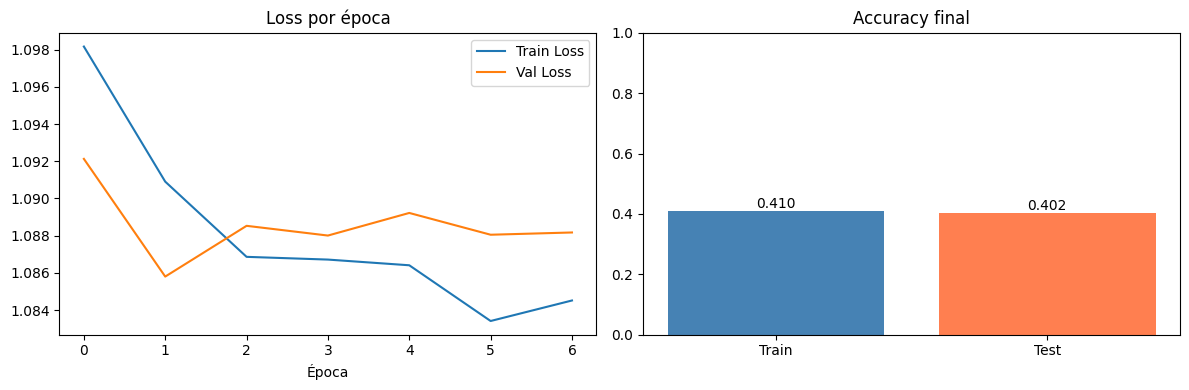

In [17]:
import matplotlib.pyplot as plt

# Predicciones
modelo.eval()
with torch.no_grad():
    logits = modelo(X_test_t)
    y_pred_enc = torch.argmax(logits, dim=1).cpu().numpy()

y_pred_labels = le.inverse_transform(y_pred_enc)
y_test_labels = le.inverse_transform(y_test_enc)

print("=== Resultados Red Neuronal MLP (PyTorch) ===")
print(classification_report(y_test_labels, y_pred_labels))

# Curvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historial_train, label='Train Loss')
ax1.plot(historial_val,   label='Val Loss')
ax1.set_title('Loss por época')
ax1.set_xlabel('Época')
ax1.legend()

# Accuracy manual
modelo.eval()
with torch.no_grad():
    preds_train = torch.argmax(modelo(X_train_t), dim=1)
    acc_train = (preds_train == y_train_t).float().mean().item()
    preds_test = torch.argmax(modelo(X_test_t), dim=1)
    acc_test = (preds_test == y_test_t).float().mean().item()

ax2.bar(['Train', 'Test'], [acc_train, acc_test], color=['steelblue', 'coral'])
ax2.set_title('Accuracy final')
ax2.set_ylim(0, 1)
for i, v in enumerate([acc_train, acc_test]):
    ax2.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

In [18]:
df_predicciones = pd.DataFrame({
    'Real':      y_test_labels,
    'Predicho':  y_pred_labels,
    'Correcto':  y_test_labels == y_pred_labels
})

print(df_predicciones.head(20))

                              Real                        Predicho  Correcto
0                        Retrasado                       Retrasado      True
1                       Adelantado                       Retrasado     False
2                        Retrasado                       Retrasado      True
3   Sin retraso o casi sin retraso                       Retrasado     False
4                        Retrasado  Sin retraso o casi sin retraso     False
5   Sin retraso o casi sin retraso                      Adelantado     False
6                       Adelantado                      Adelantado      True
7                        Retrasado                      Adelantado     False
8                       Adelantado                      Adelantado      True
9   Sin retraso o casi sin retraso  Sin retraso o casi sin retraso      True
10                      Adelantado                      Adelantado      True
11  Sin retraso o casi sin retraso                       Retrasado     False

In [2]:
pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 6.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 9.0 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 9.5 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 11.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 11.8 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [24]:
pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 13.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.4 which is incompatible.
mizani 0.14.4 requires pandas>=2.2.0, but you have pandas 2.0.3 which is incompatible.
tensorflow-macos 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 2.4.4 which is incompatible.
plotnine 0.15.3 requires pandas>=2.2.0, but you have pandas 2.0.3 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [25]:
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer
import numpy as np

# TabNet necesita los datos como numpy arrays (ya los tenemos de antes)
# X_train_arr y X_test_arr ya están listos del preprocesamiento anterior

print(f"Shape X_train: {X_train_arr.shape}")
print(f"Shape X_test:  {X_test_arr.shape}")
print(f"Clases: {le.classes_}")

Shape X_train: (9000, 628)
Shape X_test:  (1000, 628)
Clases: ['Adelantado' 'Retrasado' 'Sin retraso o casi sin retraso']


In [26]:
# Aquí es donde ocurre el "pre-entrenamiento":
# TabNet aprende la estructura de los datos SIN usar las etiquetas
# Es como enseñarle el "idioma" de tus datos antes de la tarea real

pretrainer = TabNetPretrainer(
    n_d=32,              # dimensión de las representaciones internas
    n_a=32,              # dimensión de la atención
    n_steps=3,           # pasos del mecanismo de atención
    gamma=1.3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    mask_type='sparsemax',
    verbose=1
)

pretrainer.fit(
    X_train=X_train_arr,
    eval_set=[X_test_arr],
    max_epochs=50,
    patience=10,
    batch_size=1024,
    pretraining_ratio=0.8   # oculta el 80% de los datos para que los reconstruya
)

print("Pre-entrenamiento completado.")

/opt/anaconda3/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/cn/vnbd0r_j07x20nbs2_dk9dxm0000gn/T/ipykernel_40721/3446984810.py", line 16, in <module>
    pretrainer.fit(
  File "/opt/anaconda3/lib/python3.11/site-packages/pytorch_tabnet/pretraining.py", line 159, in fit
    self._predict_epoch(eval_name, valid_dataloader)
  File "/opt/anaconda3/lib/python3.11/site-packages/pytorch_tabnet/pretraining.py", line 357, in _predict_epoch
    output, embedded_x, obf_vars = self.stack_batches(list_output,
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/pytorch_tabnet/pretraining.py", line 384, in stack_batches
    output = np.vstack(list_output)
             ^^^^^^^^^^^^^^^^^^^^^^
  File "<__array_function__ internals>", line 180, in vstack
  File "/opt/anaconda3/lib/

In [27]:
# Ahora sí usamos las etiquetas: partimos del modelo pre-entrenado
# y lo afinamos para clasificar tipo_retraso
# Esto es el fine-tuning real

modelo_tabnet = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=3,
    gamma=1.3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    mask_type='sparsemax',
    verbose=1
)

modelo_tabnet.fit(
    X_train=X_train_arr,
    y_train=y_train_enc,
    eval_set=[(X_test_arr, y_test_enc)],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=15,
    batch_size=1024,
    from_unsupervised=pretrainer   # aquí carga el pre-entrenamiento
)

print("Fine-tuning completado.")

/opt/anaconda3/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/opt/anaconda3/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 1.4643  | val_0_accuracy: 0.462   |  0:00:03s
epoch 1  | loss: 1.34021 | val_0_accuracy: 0.461   |  0:00:07s
epoch 2  | loss: 1.30387 | val_0_accuracy: 0.461   |  0:00:10s
epoch 3  | loss: 1.2881  | val_0_accuracy: 0.461   |  0:00:14s
epoch 4  | loss: 1.25215 | val_0_accuracy: 0.461   |  0:00:17s
epoch 5  | loss: 1.25854 | val_0_accuracy: 0.46    |  0:00:20s
epoch 6  | loss: 1.24111 | val_0_accuracy: 0.462   |  0:00:23s
epoch 7  | loss: 1.23156 | val_0_accuracy: 0.463   |  0:00:27s
epoch 8  | loss: 1.1953  | val_0_accuracy: 0.463   |  0:00:30s
epoch 9  | loss: 1.19295 | val_0_accuracy: 0.463   |  0:00:33s
epoch 10 | loss: 1.18883 | val_0_accuracy: 0.463   |  0:00:36s
epoch 11 | loss: 1.17834 | val_0_accuracy: 0.462   |  0:00:39s
epoch 12 | loss: 1.1601  | val_0_accuracy: 0.463   |  0:00:43s
epoch 13 | loss: 1.15861 | val_0_accuracy: 0.462   |  0:00:46s
epoch 14 | loss: 1.14266 | val_0_accuracy: 0.462   |  0:00:49s
epoch 15 | loss: 1.15021 | val_0_accuracy: 0.462   |  0

/opt/anaconda3/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Fine-tuning completado.


In [28]:
from sklearn.metrics import classification_report

y_pred_tabnet = modelo_tabnet.predict(X_test_arr)
y_pred_tabnet_labels = le.inverse_transform(y_pred_tabnet)

print("=== Resultados TabNet (Fine-tuning) ===")
print(classification_report(y_test_labels, y_pred_tabnet_labels))

=== Resultados TabNet (Fine-tuning) ===
                                precision    recall  f1-score   support

                    Adelantado       0.46      1.00      0.63       463
                     Retrasado       0.00      0.00      0.00       289
Sin retraso o casi sin retraso       0.00      0.00      0.00       248

                      accuracy                           0.46      1000
                     macro avg       0.15      0.33      0.21      1000
                  weighted avg       0.21      0.46      0.29      1000



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
